# Overview
Ten notebook jest przeznaczony do analizy algorytmów redukcji wymiarowości na zbiorze **iris**

https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html

Badamy następujace algorytmy:

- Linear Discriminant An


In [6]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
from sklearn.datasets import load_iris
import pandas as pd
from utils.scores import Dataset

iris = load_iris()
X = iris.data
y = iris.target
iris_dataset = Dataset(X, y, 'Iris')




## LDA 

In [8]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

In [7]:
from utils.lda import my_lda
model_lda = my_lda(n_components=2)
X_lda, df_lda = model_lda.fit(X_scaled, y)

NameError: name 'np' is not defined

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_lda['LDA_1'], df_lda['LDA_2'], c=y, alpha=0.8)
plt.title("LDA na Iris")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

In [ ]:
from sklearn.manifold import trustworthiness

trust_lda = trustworthiness(X_scaled, X_lda, n_neighbors=5)
print(f"Trustworthiness dla LDA: {trust_lda:.4f}")

# PCA

In [ ]:
from utils.pca import my_pca

model_pca = my_pca(n_components=2)
X_pca, df_pca = model_pca.fit(X_scaled)

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_pca['PC_1'], df_pca['PC_2'], c=y, alpha=0.8)
plt.title("PCA na Iris")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

In [ ]:
trust_pca = trustworthiness(X_scaled, X_pca, n_neighbors=5)
print(f"Trustworthiness dla PCA: {trust_pca:.4f}")

## Kernel PCA

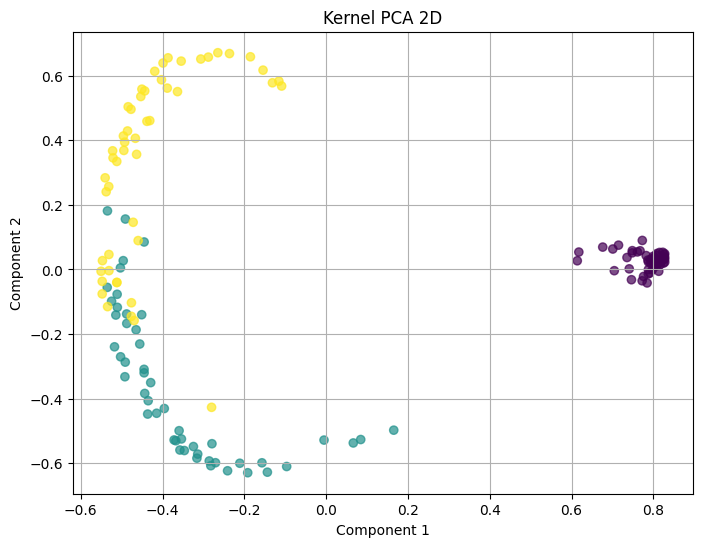

In [9]:
from sklearn.decomposition import PCA, KernelPCA

PCA_2d = KernelPCA(n_components=2, kernel='rbf')
X_pca_2d = PCA_2d.fit_transform(iris_dataset.X)
iris_dataset.plot_projection(X_pca_2d, title="Kernel PCA 2D")

In [10]:
from sklearn.manifold import trustworthiness

trustworthiness(X, X_pca_2d, n_neighbors=5)

np.float64(0.9265070422535211)

## TSNE

In [ ]:
from utils.tsne import tsne
model_tsne = tsne(n_components=2, perplexity=30)
X_tsne = model_tsne.fit_transform(X_scaled)

In [ ]:
df_tsne = pd.DataFrame(
    X_tsne,
    columns=['TSNE_1', 'TSNE_2']
)

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_tsne['TSNE_1'], df_tsne['TSNE_2'], c=y, alpha=0.8)
plt.title("t-SNE na Iris")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
trust_tsne = trustworthiness(X_scaled, X_tsne, n_neighbors=5)
print(f"Trustworthiness dla t-SNE: {trust_tsne:.4f}")

## Autoencoder

In [12]:
from utils.autoencoder import autoencoder

model_ae = Autoencoder(input_dim=X_scaled.shape[1], latent_dim=2)

model_ae.fit(X_scaled, epochs=200)
X_ae = model_ae.transform(X_scaled)

ImportError: cannot import name 'autoencoder' from 'utils.autoencoder' (/Users/wiktor/dim_red/Dimensionality-reduction-project/utils/autoencoder.py)

In [ ]:
df_ae = pd.DataFrame(X_ae, columns=["AE_1", "AE_2"])

In [ ]:
plt.scatter(df_ae["AE_1"], df_ae["AE_2"], c=y)
plt.title("Autoencoder na Iris")
plt.show()

In [ ]:
trust_ae = trustworthiness(X_scaled, X_ae, n_neighbors=5)
print(f"Trustworthiness dla Autoencodera: {trust_ae:.4f}")

# Isomap i UMAP

In [14]:
def plot_embedding(embedding, labels, title="", ax=None):
    
    """Rysuje embedding 2D, kolorując punkty wg etykiet."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(title)
    ax.grid(True, which="major", linewidth=0.5, color="gray", alpha=0.5)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


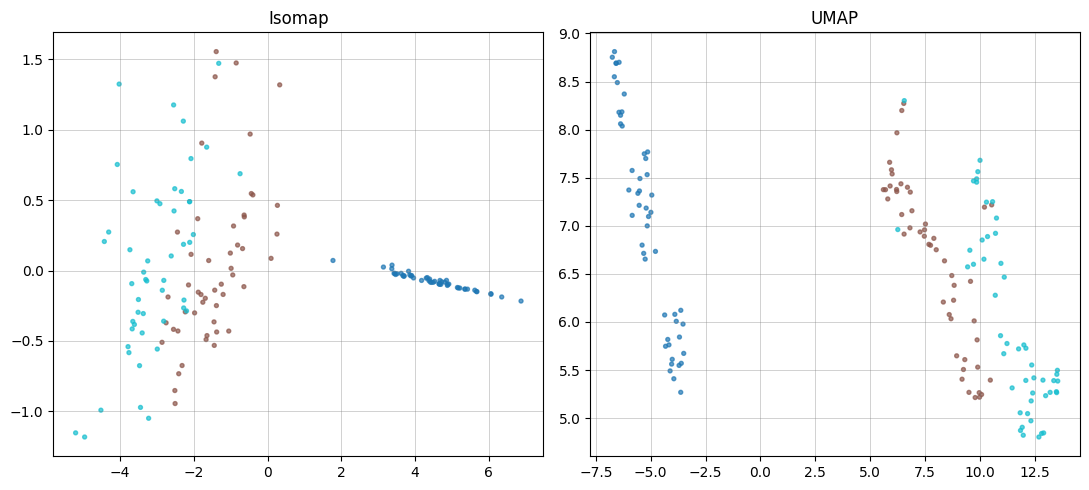

In [16]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from utils.isomap_umap import isomap, umap_reduce

X, y = load_iris(return_X_y=True)


emb_iso = isomap(X)
emb_umap = umap_reduce(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_embedding(emb_iso, y, "Isomap", ax=axes[0])
plot_embedding(emb_umap, y, "UMAP", ax=axes[1])
plt.tight_layout()
plt.show()

In [42]:
X, y = load_iris(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

neighbor_values = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]

iso_scores, umap_scores = [], []
for k in neighbor_values:
    emb_iso = isomap(X_scaled, n_neighbors=k, scale=False)
    emb_umap = umap_reduce(X_scaled, n_neighbors=k, scale=False)
    iso_scores.append(trustworthiness(X_scaled, emb_iso))
    umap_scores.append(trustworthiness(X_scaled, emb_umap))


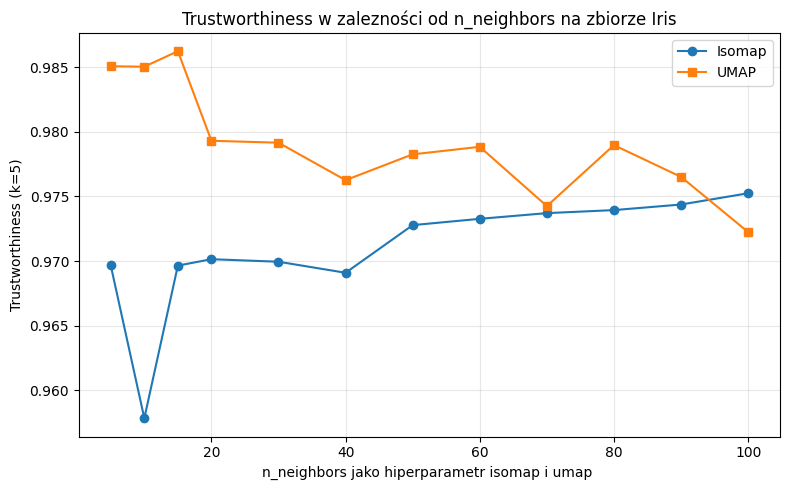

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(neighbor_values, iso_scores, "o-", label="Isomap")
plt.plot(neighbor_values, umap_scores, "s-", label="UMAP")
plt.xlabel("n_neighbors jako hiperparametr isomap i umap ")
plt.ylabel(f"Trustworthiness")
plt.title("Trustworthiness w zalezności od n_neighbors na zbiorze Iris")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
)
from utils.isomap_umap import isomap, umap_reduce

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

X, y = load_iris(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)
n_clusters = len(np.unique(y))         

neighbor_values = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]

metrics = ["NMI", "Silhouette", "Calinski-Harabasz"]
results = {m: {"isomap": [], "umap": []} for m in metrics}


In [ ]:
for k in neighbor_values:
    for name, fn in [("isomap", isomap), ("umap", umap_reduce)]:
        emb = fn(X_scaled, n_neighbors=k, scale=False)
        km = KMeans(n_clusters=n_clusters, random_state=1, n_init=10).fit_predict(emb)

        results["NMI"][name].append(normalized_mutual_info_score(y, km))   
        results["Silhouette"][name].append(silhouette_score(emb, y))    
        results["Calinski-Harabasz"][name].append(calinski_harabasz_score(emb, y))



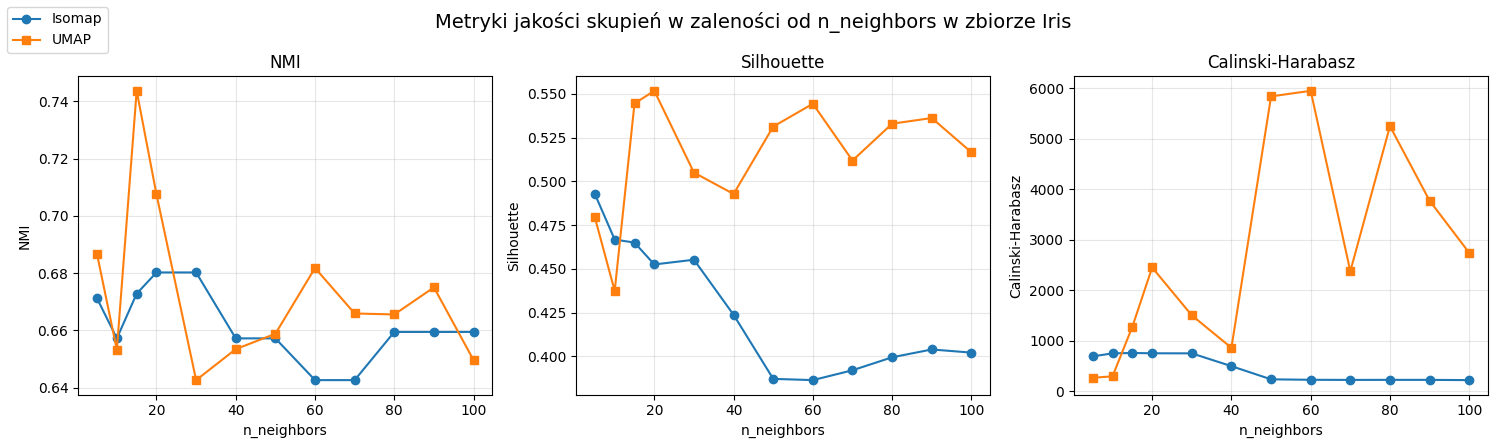

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, metrics):
    ax.plot(neighbor_values, results[metric]["isomap"], "o-", label="Isomap")
    ax.plot(neighbor_values, results[metric]["umap"], "s-", label="UMAP")
    ax.set_title(metric)
    ax.set_xlabel("n_neighbors")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=1)

fig.suptitle("Metryki jakości skupień w zaleności od n_neighbors w zbiorze Iris", fontsize=14)
fig.tight_layout()
plt.show()